In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from scipy.interpolate import InterpolatedUnivariateSpline as IUS

In [35]:
# for now grab from quickrun file
p = 10.0
e = 0.2
a = 0.5

In [211]:
r_min = p / (1.0 + e)
r_max = p / (1.0 - e)

r_mean = (r_min + r_max) / 2.0

rField = 14.0
thetaField = 1.5700

## Trajectory

In [212]:
# load data
traj_data_path = "../data/trajectory_adaptive.dat"
lam, t, r_p, phi_p, ur = np.loadtxt(traj_data_path).T

In [213]:
deltaLambda = lam[1:] - lam[:-1]
delta_lambda = np.concatenate((np.array([lam[1] - lam[0]]),deltaLambda))

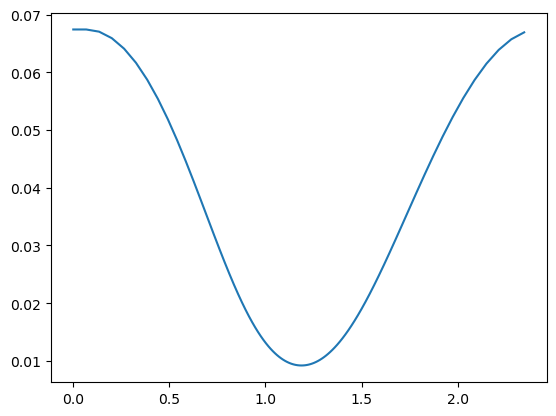

In [214]:
crangevals = delta_lambda
plt.plot(lam, crangevals)
plt.show()

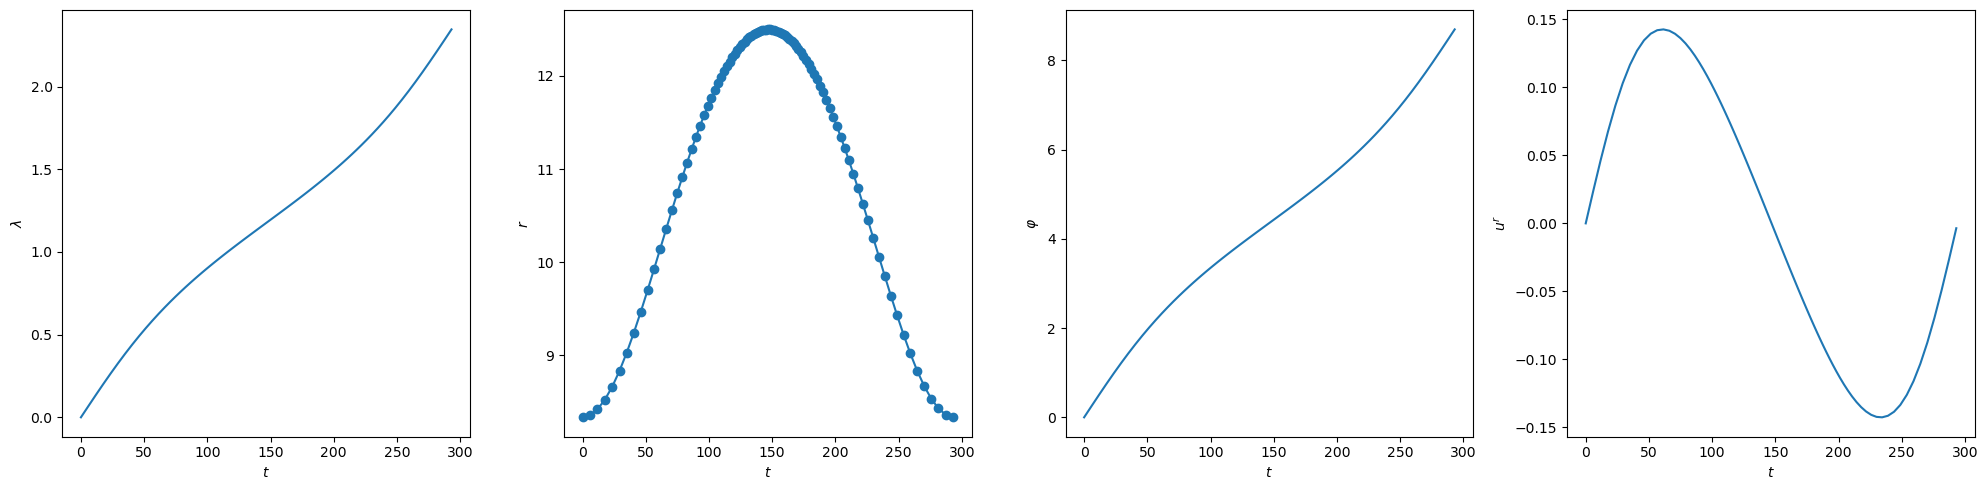

In [215]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20,5))
axs[0].plot(t,lam)
axs[0].set_ylabel(r'$\lambda$')
axs[1].plot(t,r_p)
axs[1].scatter(t,r_p)
axs[1].set_ylabel(r'$r$')
axs[2].plot(t,phi_p)
axs[2].set_ylabel(r'$\varphi$')
axs[3].plot(t,ur)
axs[3].set_ylabel(r'$u^r$')

for ax in axs:
    ax.set_xlabel(r'$t$')

plt.tight_layout()
plt.show()

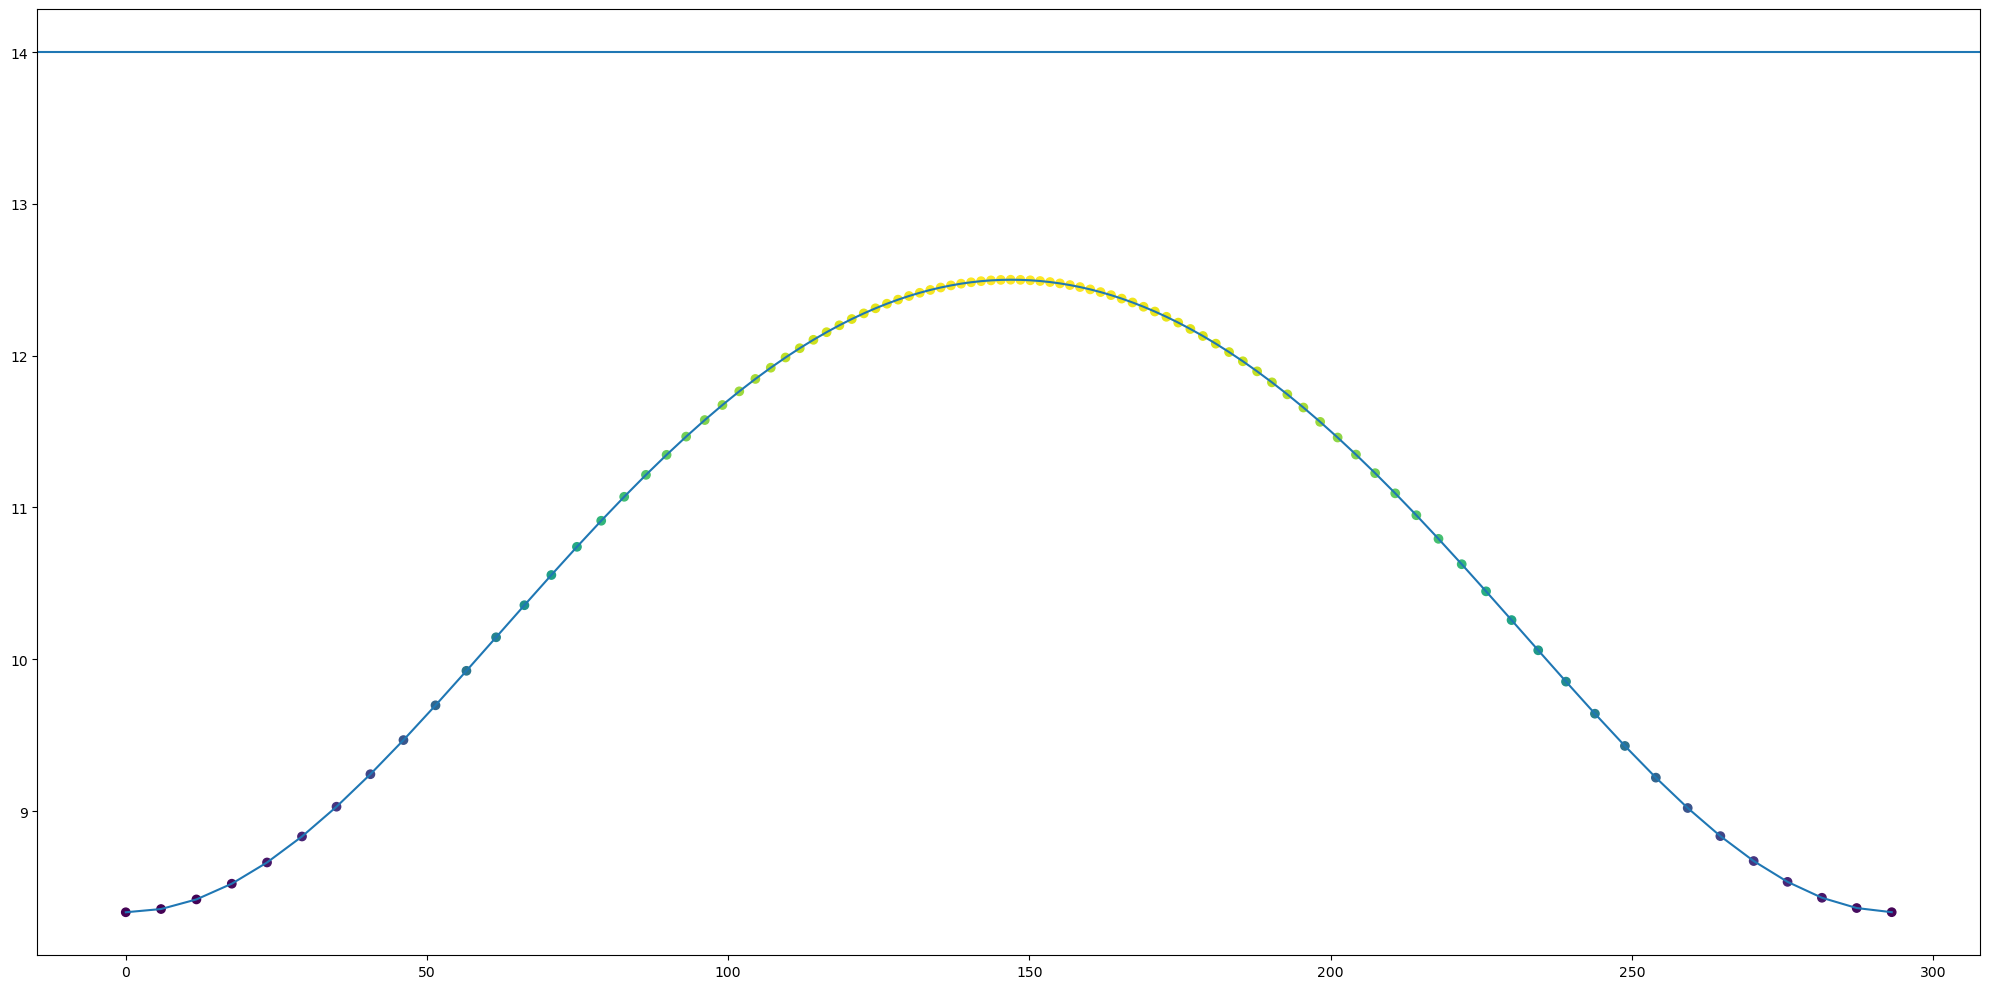

In [216]:
plt.figure(figsize=(20,10))
plt.plot(t,r_p)
plt.scatter(t,r_p, c=crangevals, cmap='viridis_r')
plt.axhline(y=rField)


plt.tight_layout()
plt.show()

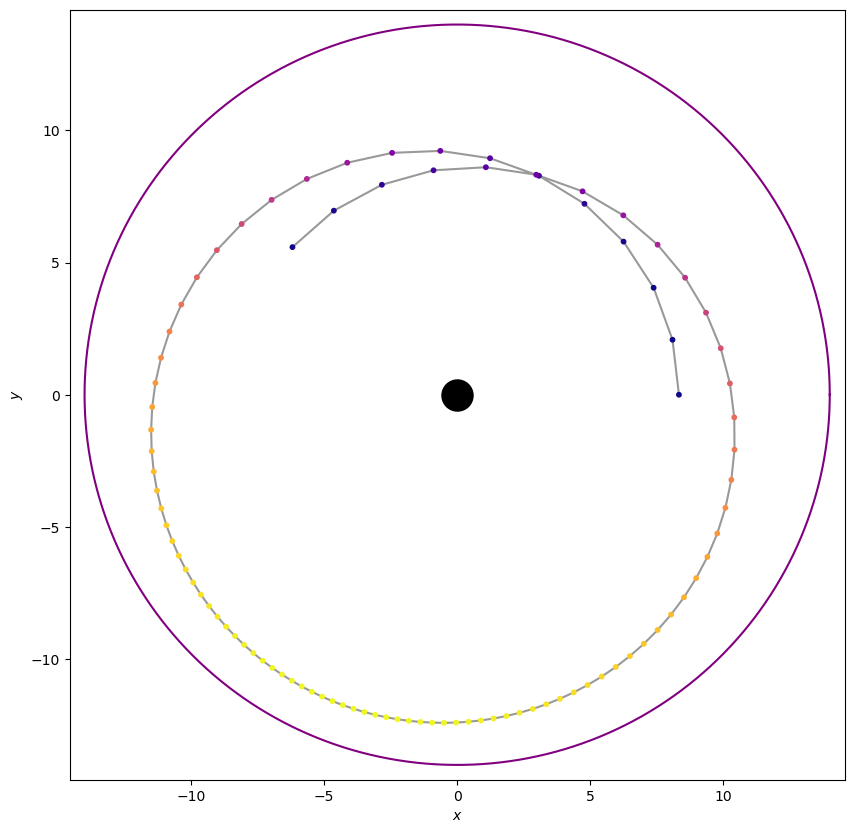

In [219]:
plt.figure(figsize=(10,10))
rmax = np.max([rField, np.max(r_p)])*1.04
plt.plot(r_p*np.cos(phi_p), r_p*np.sin(phi_p),c='k',alpha=0.4)
plt.scatter(r_p*np.cos(phi_p), r_p*np.sin(phi_p), s=10,zorder=10,c=crangevals, cmap='plasma_r')
plt.scatter(0,0, s=500, c='k')

plot_thetas = np.linspace(0,2*np.pi,num=1000)
plt.plot(rField*np.cos(plot_thetas), rField*np.sin(plot_thetas), c='purple')

tidx = np.argmin(np.abs(t-235.75))
# plt.scatter(r_p[tidx]*np.cos(phi_p[tidx]),r_p[tidx]*np.sin(phi_p[tidx]),c='r',s=100,zorder=100,marker='x')

plt.xlim(-rmax, rmax)
plt.ylim(-rmax, rmax)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.show()

# Timeseries Field

In [220]:
full_data = np.genfromtxt('../data/field_adaptive.dat', delimiter=",").T
t = full_data[0]
field = full_data[1] + 1j*full_data[2]
src = full_data[3] + 1j*full_data[4]
dr_field = full_data[5] + 1j*full_data[6]
dth_field = full_data[7] + 1j*full_data[8]

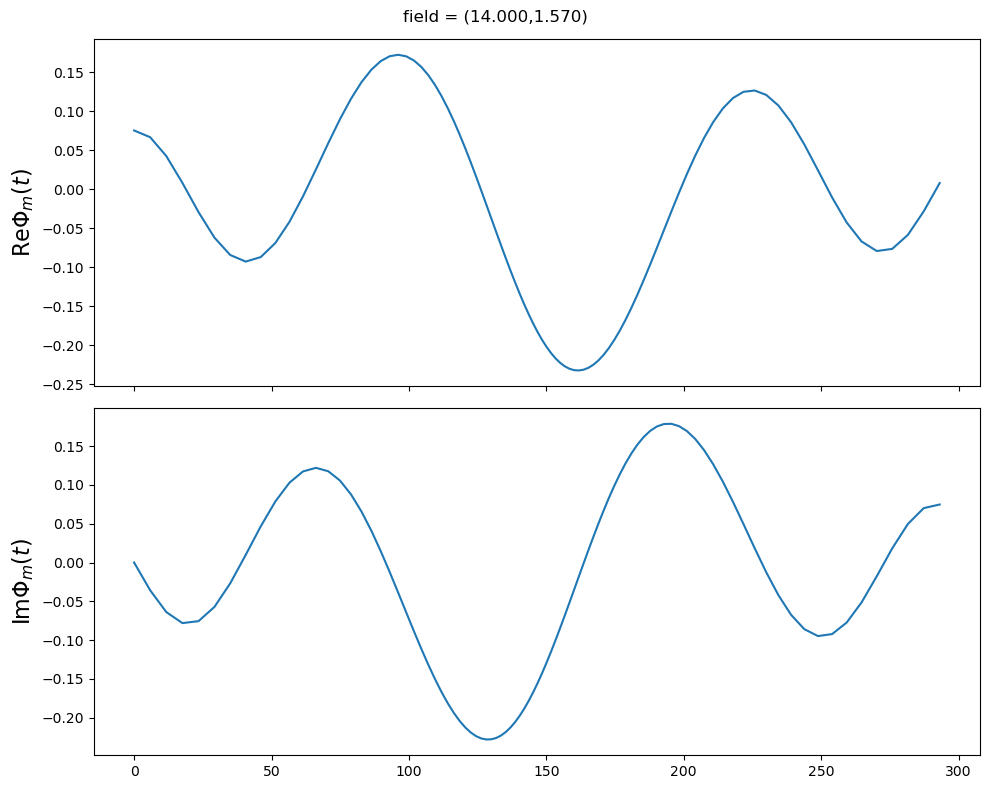

In [221]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

axs[0].plot(t,field.real)
axs[0].set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)
axs[1].plot(t,field.imag)
axs[1].set_ylabel(r'Im$\Phi_m(t)$',fontsize=16)

plt.suptitle(f"field = ({rField:0.3f},{thetaField:0.3f})")
plt.tight_layout()
plt.show()

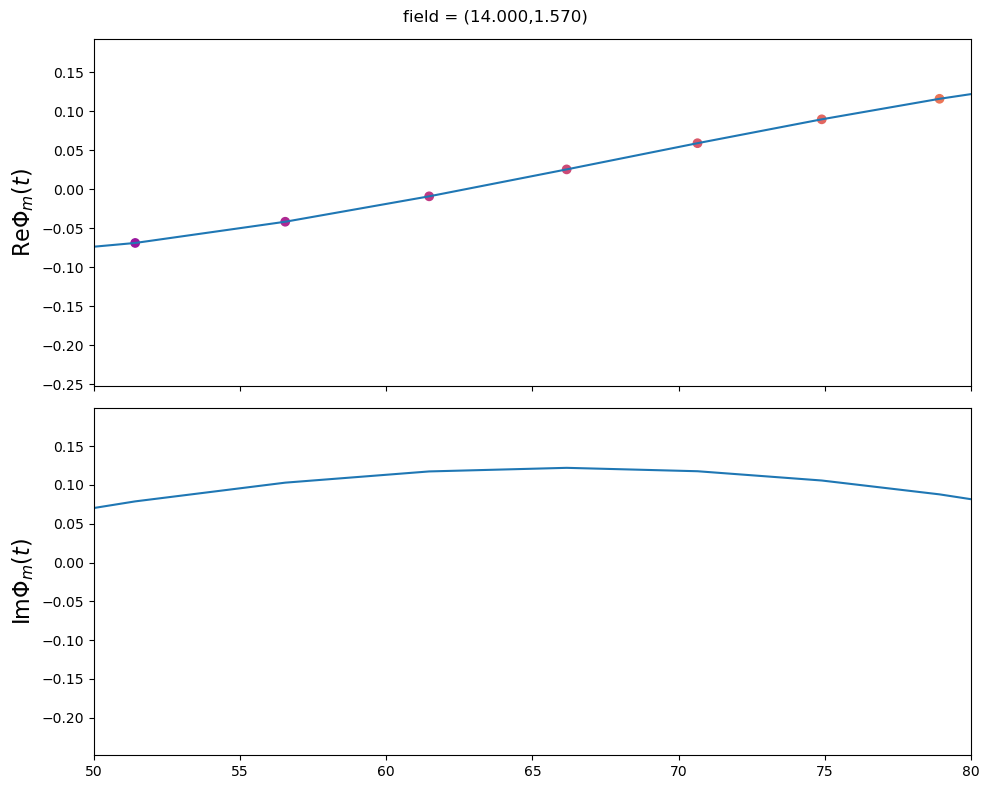

In [222]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

axs[0].plot(t,field.real)
axs[0].scatter(t,field.real,c=crangevals, cmap='plasma_r')
axs[0].set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)
axs[1].plot(t,field.imag)
axs[1].set_ylabel(r'Im$\Phi_m(t)$',fontsize=16)

axs[1].set_xlim(50,80)

plt.suptitle(f"field = ({rField:0.3f},{thetaField:0.3f})")
plt.tight_layout()
plt.show()

# Source

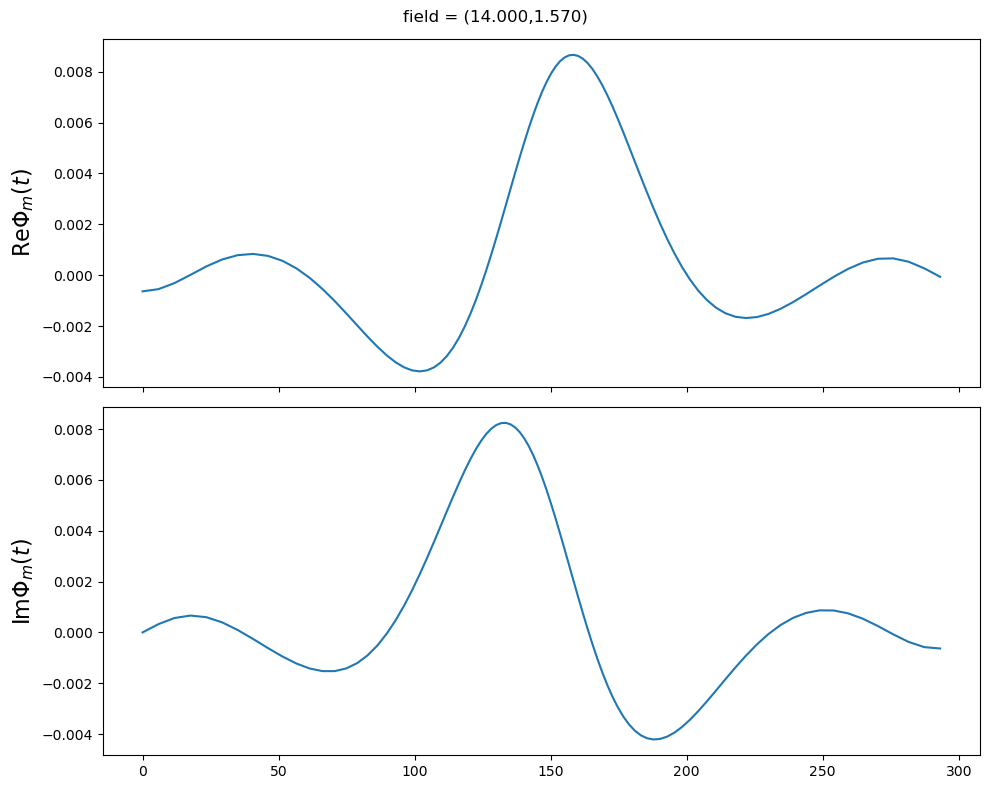

In [223]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

axs[0].plot(t,src.real)
axs[0].set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)
axs[1].plot(t,src.imag)
axs[1].set_ylabel(r'Im$\Phi_m(t)$',fontsize=16)

plt.suptitle(f"field = ({rField:0.3f},{thetaField:0.3f})")
plt.tight_layout()
plt.show()

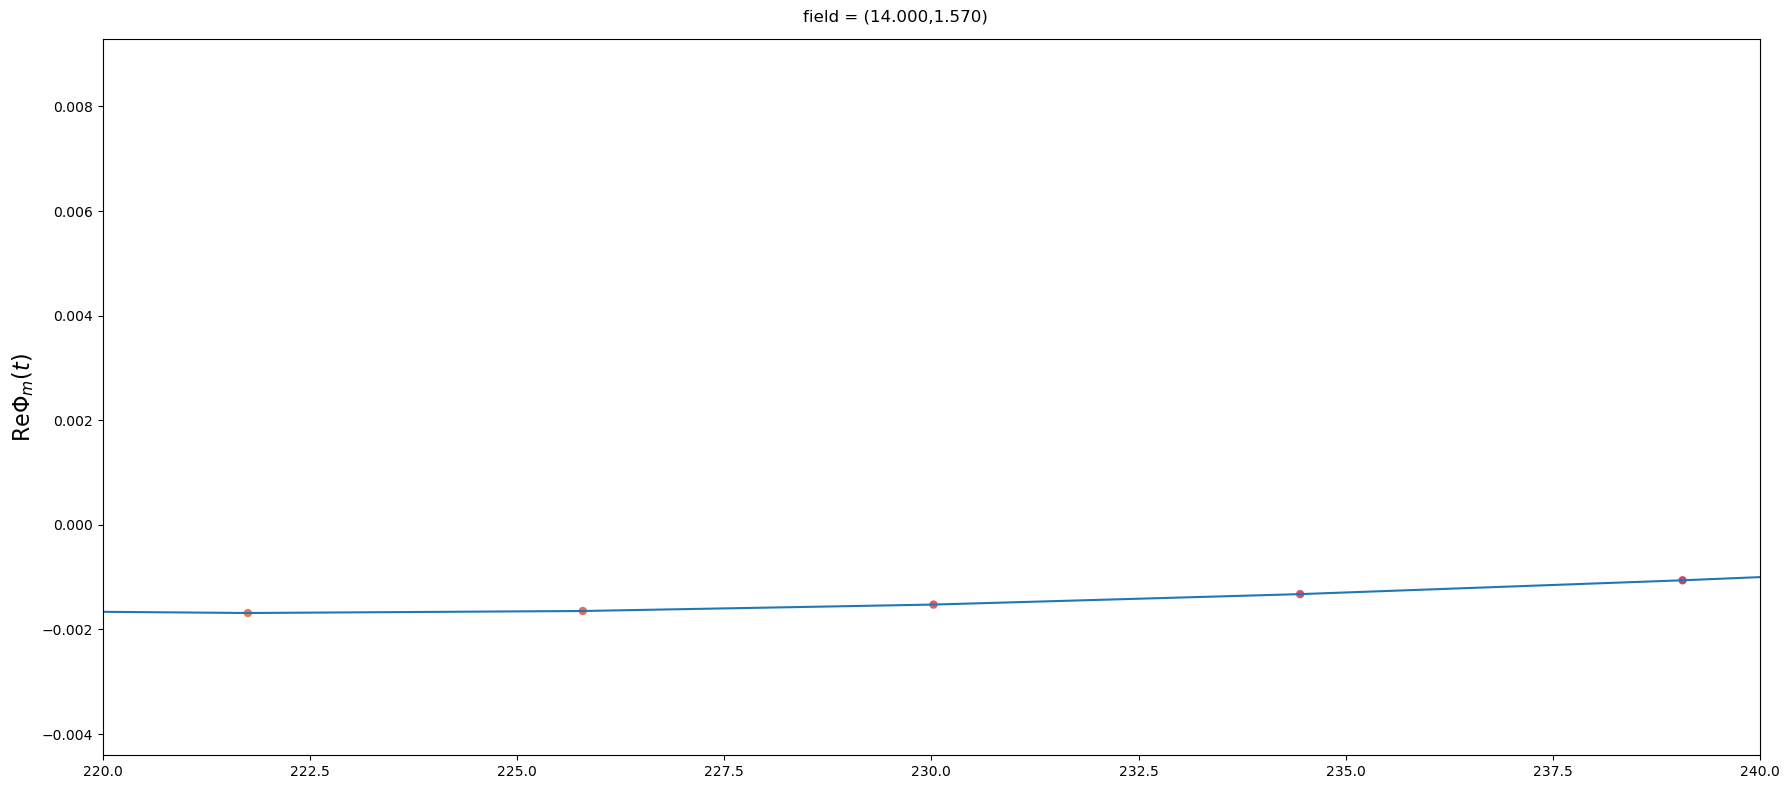

In [224]:
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(18,8), sharex=True)

axs.plot(t,src.real)
axs.scatter(t,src.real,c=crangevals, cmap='plasma_r', s=25)
axs.set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)

axs.set_xlim(220,240)

plt.suptitle(f"field = ({rField:0.3f},{thetaField:0.3f})")
plt.tight_layout()
plt.show()

# dtheta

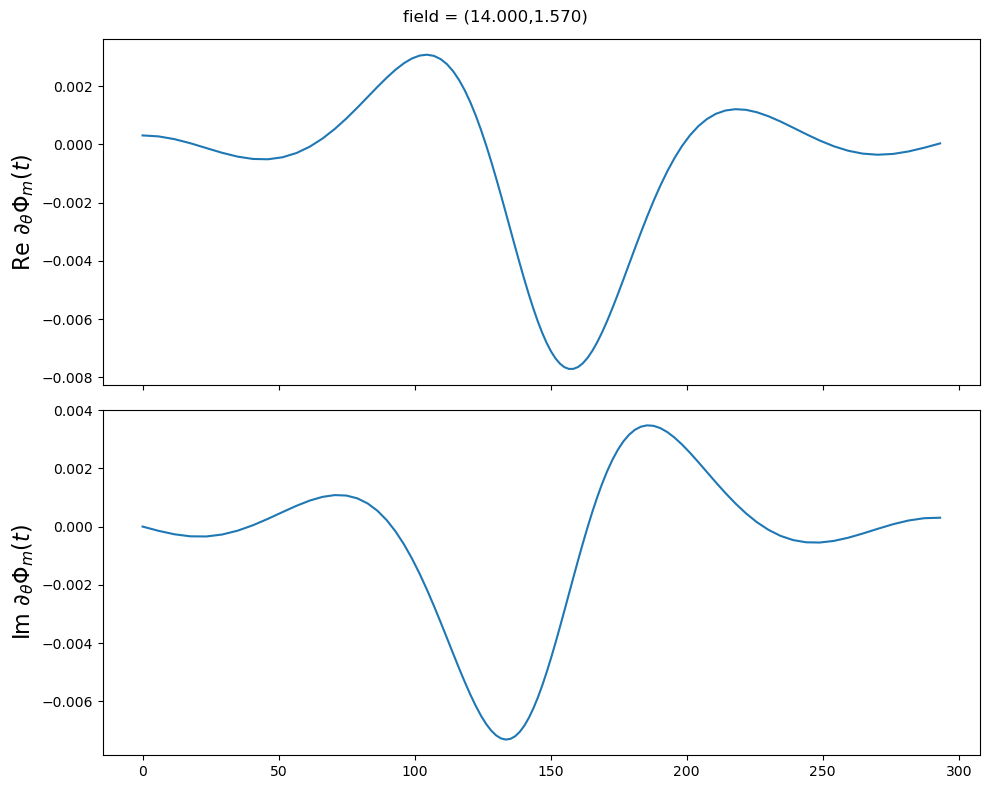

In [225]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

axs[0].plot(t,dth_field.real)
axs[0].set_ylabel(r'Re $\partial_\theta\Phi_m(t)$',fontsize=16)
axs[1].plot(t,dth_field.imag)
axs[1].set_ylabel(r'Im $\partial_\theta\Phi_m(t)$',fontsize=16)

plt.suptitle(f"field = ({rField:0.3f},{thetaField:0.3f})")
plt.tight_layout()
plt.show()

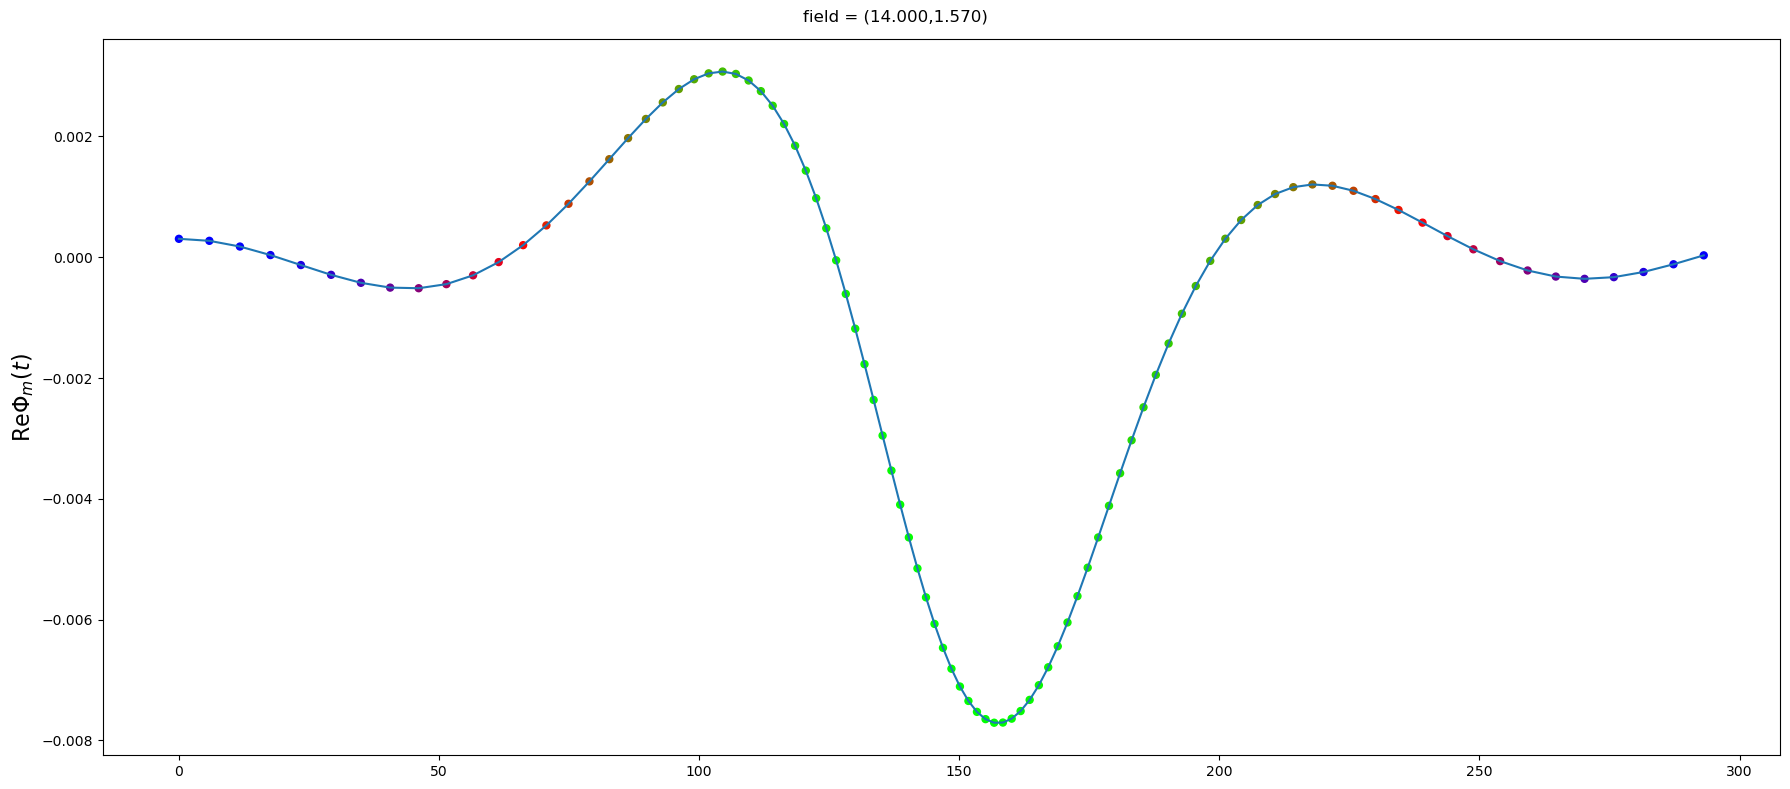

In [227]:
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(18,8), sharex=True)

axs.plot(t,dth_field.real)
axs.scatter(t,dth_field.real,c=crangevals, cmap='brg_r', s=25)
axs.set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)

# axs.set_xlim(100,300)|

plt.suptitle(f"field = ({rField:0.3f},{thetaField:0.3f})")
plt.tight_layout()
plt.show()